### Importación de datos



In [2]:
import pandas as pd

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_1%20.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_4.csv"

tienda = pd.read_csv(url)
tienda2 = pd.read_csv(url2)
tienda3 = pd.read_csv(url3)
tienda4 = pd.read_csv(url4)

tienda.head()

,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
0,Asistente virtual,Electrónicos,164300.0,6900.0,16/01/2021,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.60971,-74.08175
1,Mesa de comedor,Muebles,192300.0,8400.0,18/05/2022,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25184,-75.56359
2,Juego de mesa,Juguetes,209600.0,15900.0,15/03/2021,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.39972,-75.51444
3,Microondas,Electrodomésticos,757500.0,41000.0,03/05/2022,Juan Fernandez,Cali,4,Nequi,1,3.43722,-76.52250
4,Silla de oficina,Muebles,335200.0,20200.0,07/11/2020,Maria Alfonso,Medellín,5,Nequi,1,6.25184,-75.56359


#1. Análisis de facturación



In [3]:
precioTienda = tienda['Precio'].sum()
precioTienda2 = tienda2['Precio'].sum()
precioTienda3 = tienda3['Precio'].sum()
precioTienda4 = tienda4['Precio'].sum()
print(f"{precioTienda} - {precioTienda2} - {precioTienda3} - {precioTienda4}")

1150880400.0 - 1116343500.0 - 1098019600.0 - 1038375700.0


# 2. Ventas por categoría

In [4]:
tienda['Calificación'].unique()

array([4, 1, 5, 3, 2])

In [71]:
tienda['Producto'].value_counts().head(5)

,count
Producto,
Microondas,60
TV LED UHD 4K,60
Armario,60
Secadora de ropa,58
Mesa de noche,56


In [6]:
tienda['Categoría del Producto'].unique()

array(['Electrónicos', 'Muebles', 'Juguetes', 'Electrodomésticos',
       'Artículos para el hogar', 'Deportes y diversión', 'Libros',
       'Instrumentos musicales'], dtype=object)

In [ ]:
dir(tienda)

<Axes: xlabel='Producto'>

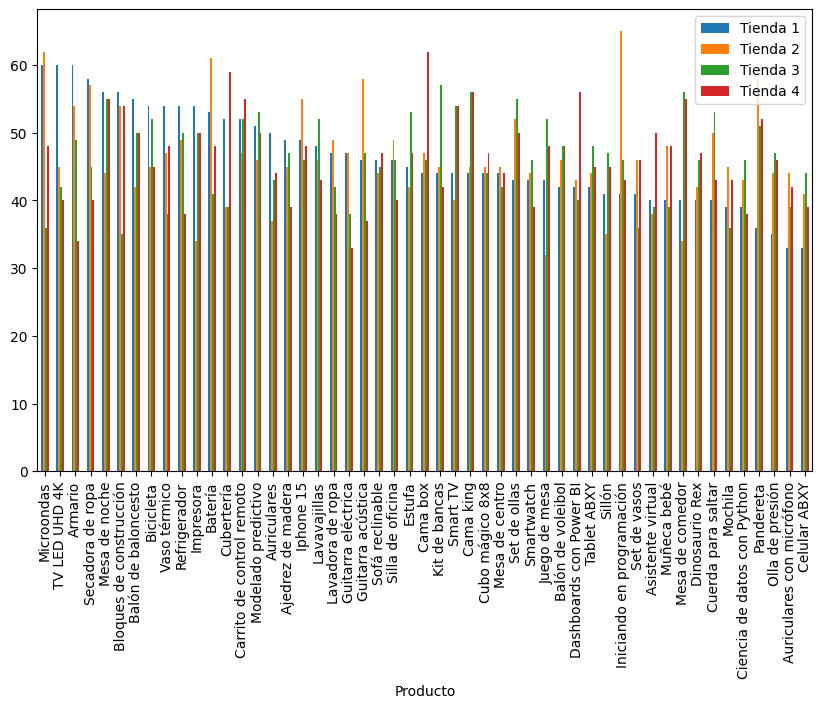

In [22]:
ventas_productos1 = tienda['Producto'].value_counts()
ventas_productos2 = tienda2['Producto'].value_counts()
ventas_productos3 = tienda3['Producto'].value_counts()
ventas_productos4 = tienda4['Producto'].value_counts()

comparacion_productos = pd.concat(
    [ventas_productos1, ventas_productos2, ventas_productos3, ventas_productos4],
    axis=1
)

comparacion_productos.columns = ['Tienda 1', 'Tienda 2', 'Tienda 3', 'Tienda 4']
comparacion_productos = comparacion_productos.fillna(0)

comparacion_productos.plot(kind='bar', figsize=(10,6))

<Axes: xlabel='Categoría del Producto'>

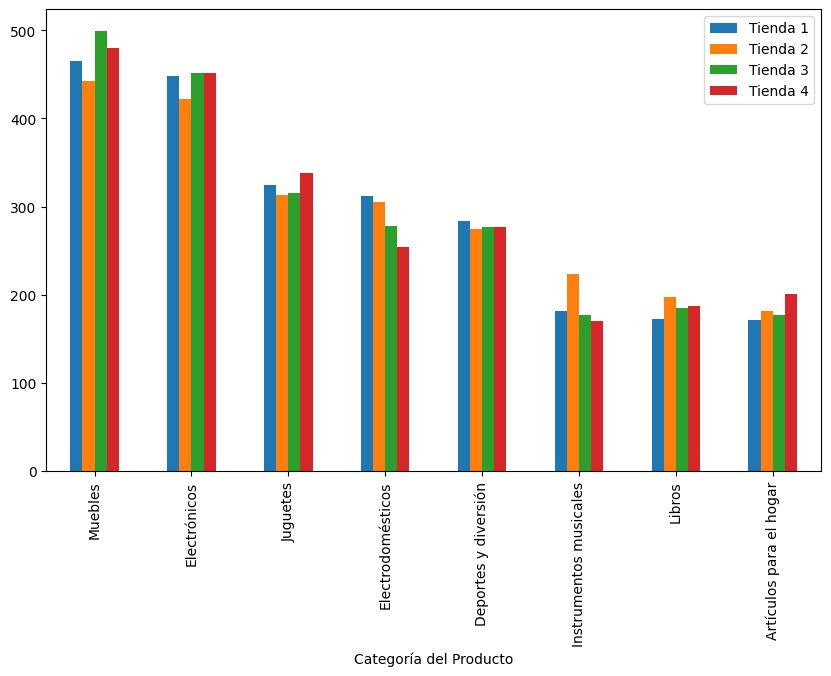

In [57]:
ventas_categorias1 = tienda['Categoría del Producto'].value_counts()
ventas_categorias2 = tienda2['Categoría del Producto'].value_counts()
ventas_categorias3 = tienda3['Categoría del Producto'].value_counts()
ventas_categorias4 = tienda4['Categoría del Producto'].value_counts()

comparacion_categorias = pd.concat(
    [ventas_categorias1, ventas_categorias2, ventas_categorias3, ventas_categorias4],
    axis=1
)

comparacion_categorias.columns = ['Tienda 1', 'Tienda 2', 'Tienda 3', 'Tienda 4']
comparacion_categorias = comparacion_categorias.fillna(0)

comparacion_categorias.plot(kind='bar', figsize=(10,6))

# 3. Calificación promedio de la tienda


<Axes: >

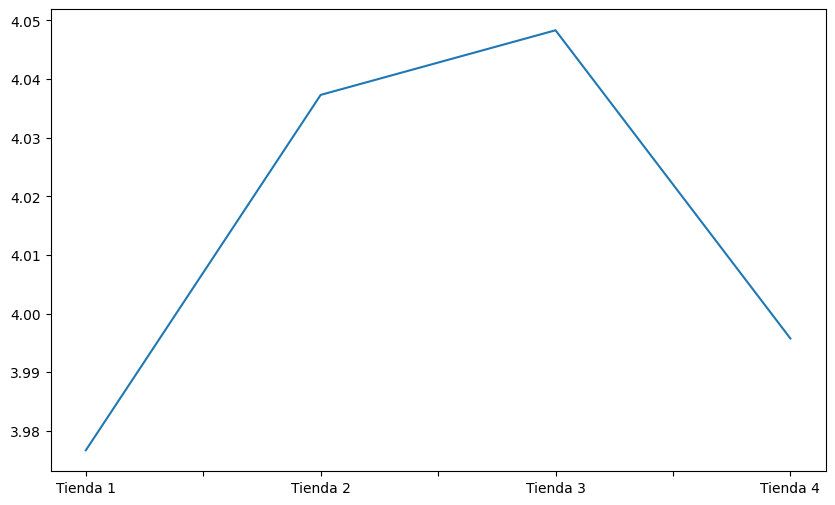

In [55]:
promedio_calificación1 = tienda['Calificación'].mean()
promedio_calificación2 = tienda2['Calificación'].mean()
promedio_calificación3 = tienda3['Calificación'].mean()
promedio_calificación4 = tienda4['Calificación'].mean()

comparacion_calificacion = pd.Series(
    [
        promedio_calificación1,
        promedio_calificación2,
        promedio_calificación3,
        promedio_calificación4
    ],
    index=['Tienda 1', 'Tienda 2', 'Tienda 3', 'Tienda 4']
)

comparacion_calificacion.plot(kind='line', figsize=(10,6))

In [33]:
print(f"{promedio_calificación1}, {promedio_calificación2}, {promedio_calificación3}, {promedio_calificación4}")

3.976685036032217, 4.037303942348453, 4.048325561678677, 3.9957591178965224


# 4. Productos más y menos vendidos

<Axes: xlabel='Producto'>

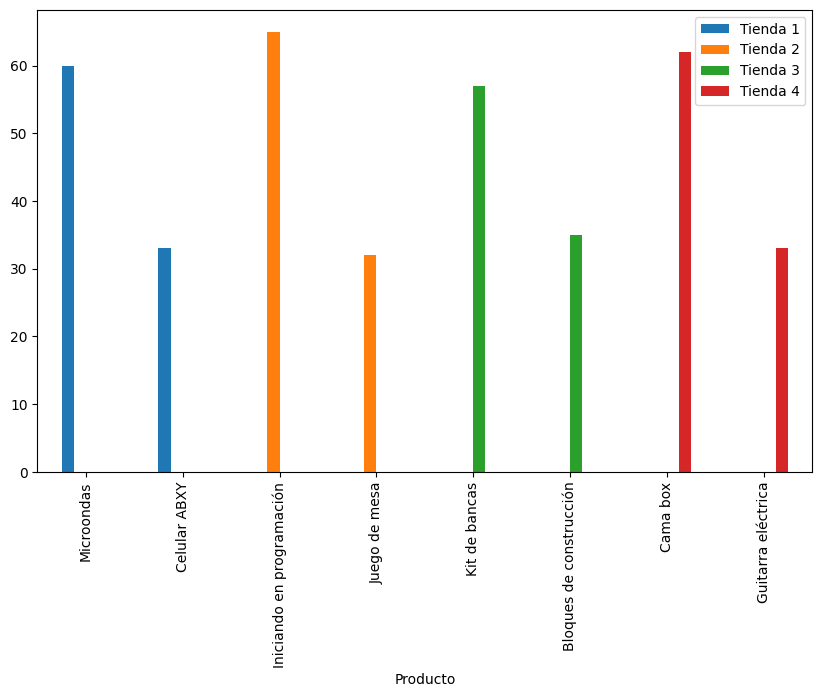

In [81]:
mp_tienda1 = pd.concat([ventas_productos1.head(1), ventas_productos1.tail(1)])
mp_tienda2 = pd.concat([ventas_productos2.head(1), ventas_productos2.tail(1)])
mp_tienda3 = pd.concat([ventas_productos3.head(1), ventas_productos3.tail(1)])
mp_tienda4 = pd.concat([ventas_productos4.head(1), ventas_productos4.tail(1)])

comparacion_mp = pd.concat(
    [mp_tienda1, mp_tienda2, mp_tienda3, mp_tienda4],
    axis=1
)

comparacion_mp.columns = ['Tienda 1', 'Tienda 2', 'Tienda 3', 'Tienda 4']
comparacion_mp = comparacion_mp.fillna(0)

comparacion_mp.plot(kind='bar', figsize=(10,6))

# 5. Envío promedio por tienda

In [50]:
promedio_envio1 = tienda['Costo de envío'].mean()
promedio_envio2 = tienda2['Costo de envío'].mean()
promedio_envio3 = tienda3['Costo de envío'].mean()
promedio_envio4 = tienda4['Costo de envío'].mean()

print(f"{promedio_envio1}, {promedio_envio2}, {promedio_envio3}, {promedio_envio4}")

26018.60958033065, 25216.235693090293, 24805.680373039424, 23459.457167090754


<Axes: >

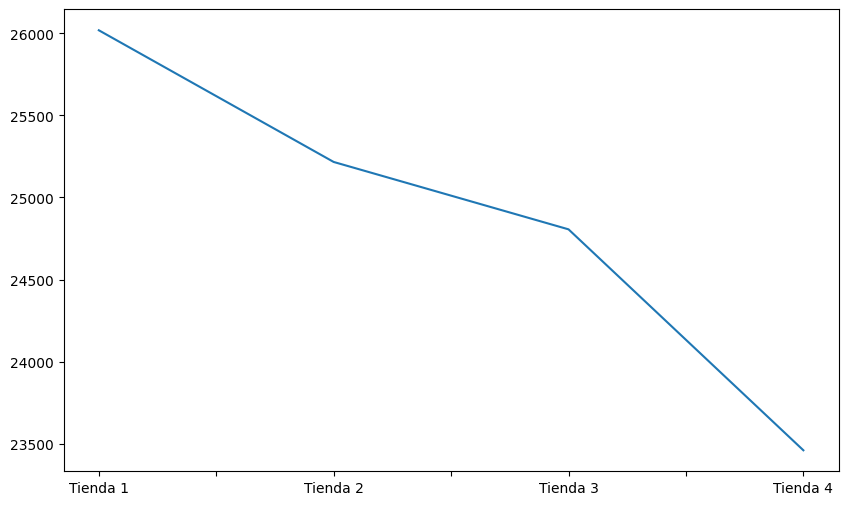

In [72]:
comparacion_envio = pd.Series(
    [promedio_envio1, promedio_envio2, promedio_envio3, promedio_envio4],
    index=['Tienda 1', 'Tienda 2', 'Tienda 3', 'Tienda 4']
)

comparacion_envio.plot(kind='line', figsize=(10,6))